# Avance 5 — Modelos de ensamble

**Proyecto Integrador — Equipo 11**
- Alicia Canta Pandal
- Miguel Silva Ramos
- Marco Antonio Corona Ruiz

Fecha:  07 de junio 2026

---

## Objetivo

Este avance aborda las competencias **3.5** y **3.6** del proyecto integrador:

- **3.5** Mejorar significativamente el rendimiento al aprovechar las fortalezas de diferentes modelos y reducir sus debilidades.*

- **3.6** Evaluar la calidad de las predicciones del modelo en datos no vistos.*

Instrucciones:

1. En esta etapa se busca crear una variedad de modelos de ensamble para solucionar el problema planteado. Para ello, deberán tomar en cuenta las siguientes consideraciones:
Incluir la optimización de hiperparámetros para los modelos más relevantes.
Utilizar algoritmos que apliquen tanto estrategias de ensamble homogéneas como heterogéneas.
Para las estrategias de stacking y/o blending, se deberán emplear los modelos individuales de mejor rendimiento obtenidos en la fase anterior.


2. Una vez que se han generado los modelos de ensamble, sintetizar los resultados en una tabla comparativa en la que se incluyan los modelos individuales de la fase previa.
Los modelos deben ser ordenados por la métrica principal, pero el resumen debe incorporar otras métricas pertinentes.
Se deberán incluir también los tiempos de entrenamiento.
Se elige el modelo final alineado con los objetivos y necesidades del negocio.


3. Del modelo elegido, generar algunos gráficos significativos con su interpretación. La siguiente lista proporciona ejemplos, pero no es exhaustiva:
Curva ROC
Matriz de confusión
Curva de Precisión-Recall
Análisis de residuos
Gráfico de importancia de características
Tendencia y predicción (para series temporales)
Diagrama de árbol (para árboles de decisión)

---

## Resumen del proyecto (Avances 1–5)

| Avance | Fase CRISP-ML(Q) | Hallazgo clave |
|--------|-----------------|----------------|
| **1** | Business & Data Understanding | Dataset LADDER balanceado (50/50); sesgo positivo en longitud; outliers válidos |
| **2** | Data Engineering | Creación de `threat_composite_score` (CTS); PCA: 3 componentes ≥ 90% varianza |
| **3** | Model Engineering (Baseline) | LogReg + TF-IDF: F1_test = 0.804, ROC-AUC = 0.865; umbral mínimo F1 ≥ 0.75 cumplido |
| **4** | Model Engineering (Alternativos) | Exploración de 8 modelos individuales, ajuste fino, selección final |
| **5 (este)** | Model Ensamble | Optimizar el modelo final y comparativa con los modelos individuales |

# ThreatLLM - búsqueda del objetivo de accuracy > 85%

Este notebook retoma la fase final de `ThreatLLM` con una meta operativa adicional: llevar el clasificador de `sentence_classification` a un **accuracy superior al 85%** sin deteriorar demasiado las demás métricas ni caer en un sobreajuste evidente.

La estrategia seguida aquí tiene dos bloques. Primero, se reconstruyen los modelos y ensambles clásicos sobre `sentence_classification`. Después, se incorpora evidencia textual auxiliar proveniente de otros componentes de LADDER (`entity_extraction` y `attack-pattern-matching-gt`) para reforzar la clase positiva sin inventar features manuales. Con ello, el pipeline sigue trabajando solo con texto real del dataset.


## 1. Carga de datos y utilidades

En esta sección se cargan los splits de `sentence_classification`, el dataset `attack-pattern-matching-gt`, y los archivos de `entity_extraction`. También se definen funciones auxiliares para métricas, extracción de spans de ataque y evaluación homogénea de los modelos.

Una decisión importante de esta fase es que, para evaluar de forma justa los modelos reforzados con datos auxiliares, se filtran **solapamientos exactos** entre los spans auxiliares y el conjunto `test` de `sentence_classification`. Así se evita reportar una mejora artificial por fuga de información literal.


In [ ]:
import os
import re
import json
import time
import warnings
from pathlib import Path

os.environ["MPLCONFIGDIR"] = "/private/tmp/mpl-threatllm-target85"
Path("/private/tmp/mpl-threatllm-target85").mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SC_BASE = Path("/Users/migsilva/Downloads/LADDER-main/attack_pattern/data/sentence_classification")
EE_BASE = Path("/Users/migsilva/Downloads/LADDER-main/attack_pattern/data/entity_extraction")
AP_PATH = Path("/Users/migsilva/Downloads/attack-pattern-matching-gt.csv")
REPORT_PATH = Path("/Users/migsilva/Downloads/litepower.txt")


def load_split(name: str) -> pd.DataFrame:
    df = pd.read_csv(SC_BASE / f"{name}.csv", sep="\t", encoding="utf-8")
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    return df


train_df = load_split("train")
dev_df = load_split("dev")
test_df = load_split("test")
ap_df_raw = pd.read_csv(AP_PATH)


def normalize_text(text: str) -> str:
    return " ".join(str(text).lower().split())


def dedup_keep_order(items):
    seen = set()
    ordered = []
    for item in items:
        key = normalize_text(item)
        if key not in seen:
            seen.add(key)
            ordered.append(str(item))
    return ordered


def parse_entity_spans(path: Path) -> list[str]:
    sentences = []
    tokens = []
    labels = []

    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line:
            if tokens:
                sentences.append((tokens, labels))
                tokens, labels = [], []
            continue
        token, label = line.rsplit(" ", 1)
        tokens.append(token)
        labels.append(label)

    if tokens:
        sentences.append((tokens, labels))

    spans = []
    for toks, labs in sentences:
        current = []
        for tok, lab in zip(toks, labs):
            if lab != "O":
                current.append(tok)
            else:
                if current:
                    span = " ".join(current).strip()
                    if len(span.split()) >= 2:
                        spans.append(span)
                    current = []
        if current:
            span = " ".join(current).strip()
            if len(span.split()) >= 2:
                spans.append(span)

    return dedup_keep_order(spans)


entity_train_spans = parse_entity_spans(EE_BASE / "train.txt")
entity_dev_spans = parse_entity_spans(EE_BASE / "dev.txt")
entity_test_spans = parse_entity_spans(EE_BASE / "test.txt")
entity_all_spans = dedup_keep_order(entity_train_spans + entity_dev_spans + entity_test_spans)

sentence_test_norm = set(test_df["text"].map(normalize_text))
entity_filtered_spans = [s for s in entity_all_spans if normalize_text(s) not in sentence_test_norm]
attack_filtered_texts = [
    s for s in dedup_keep_order(ap_df_raw["text"].astype(str).tolist())
    if normalize_text(s) not in sentence_test_norm
]


def get_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X).astype(float)


def metric_bundle(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def evaluate_builder(
    model_name: str,
    builder,
    train_texts,
    train_labels,
    category: str,
    family: str,
    note: str,
):
    estimator = builder()
    t0 = time.perf_counter()
    estimator.fit(train_texts, train_labels)
    fit_seconds = time.perf_counter() - t0

    rows = []
    for split_name, df in [("train_orig", train_df), ("dev", dev_df), ("test", test_df)]:
        y_true = df["label"].to_numpy(dtype=int)
        y_pred = estimator.predict(df["text"].astype(str))
        y_score = get_scores(estimator, df["text"].astype(str))
        metrics = metric_bundle(y_true, y_pred, y_score)
        rows.append(
            {
                "model": model_name,
                "category": category,
                "family": family,
                "note": note,
                "split": split_name,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"],
                "fit_seconds": fit_seconds,
            }
        )
    return estimator, rows


print("Shapes:")
print("train:", train_df.shape)
print("dev:  ", dev_df.shape)
print("test: ", test_df.shape)

print("\nDistribución de clases en sentence_classification:")
for split_name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    print(split_name, df["label"].value_counts().sort_index().to_dict())

print("\nVolumen de evidencia auxiliar:")
print("entity_train_spans:", len(entity_train_spans))
print("entity_dev_spans:  ", len(entity_dev_spans))
print("entity_test_spans: ", len(entity_test_spans))
print("entity_all_spans:  ", len(entity_all_spans))
print("entity_filtered_spans (sin overlap exacto con test):", len(entity_filtered_spans))
print("attack_filtered_texts:", len(attack_filtered_texts))


Shapes:
train: (2214, 2)
dev:   (568, 2)
test:  (662, 2)

Distribución de clases en sentence_classification:
train {0: 1107, 1: 1107}
dev {0: 284, 1: 284}
test {0: 331, 1: 331}

Volumen de evidencia auxiliar:
entity_train_spans: 1381
entity_dev_spans:   394
entity_test_spans:  398
entity_all_spans:   2127
entity_filtered_spans (sin overlap exacto con test): 2067
attack_filtered_texts: 80


Matplotlib is building the font cache; this may take a moment.


## 2. Modelos de referencia y ensambles clásicos

Aquí se reconstruyen los modelos fuertes ya observados en los avances previos: `Logistic Regression`, `Linear SVM`, `Soft Voting` y `Bagging Logistic`. Todos estos modelos se entrenan **solo con `sentence_classification`**, de manera que actúen como línea base real antes de introducir refuerzo auxiliar.

Este bloque nos permite medir el techo natural del dataset principal usando representaciones clásicas de texto. Si incluso los mejores ensambles tradicionales no rompen el 85%, entonces queda justificado buscar una estrategia adicional dentro de LADDER.


In [ ]:
X_train_main = train_df["text"].astype(str).tolist()
y_train_main = train_df["label"].astype(int).tolist()


def make_ref_logreg():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    min_df=1,
                    lowercase=True,
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    C=2.0,
                    class_weight="balanced",
                    solver="liblinear",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_ref_svm():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    sublinear_tf=True,
                    min_df=1,
                    lowercase=True,
                ),
            ),
            (
                "clf",
                CalibratedClassifierCV(
                    LinearSVC(
                        C=1.0,
                        class_weight="balanced",
                        max_iter=20000,
                        random_state=RANDOM_STATE,
                    ),
                    cv=3,
                ),
            ),
        ]
    )


def make_ref_soft_voting():
    return VotingClassifier(
        estimators=[
            ("lr", make_ref_logreg()),
            ("svm", make_ref_svm()),
        ],
        voting="soft",
        weights=[2, 1],
        n_jobs=1,
    )


def make_ref_bagging():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    sublinear_tf=True,
                    min_df=1,
                    lowercase=True,
                ),
            ),
            (
                "clf",
                BaggingClassifier(
                    estimator=LogisticRegression(
                        C=3.0,
                        class_weight="balanced",
                        solver="liblinear",
                        max_iter=5000,
                        random_state=RANDOM_STATE,
                    ),
                    n_estimators=15,
                    max_samples=0.8,
                    bootstrap=True,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


reference_builders = {
    "Ref - Logistic Regression": (make_ref_logreg, "Individual", "Solo sentence_classification"),
    "Ref - Linear SVM": (make_ref_svm, "Individual", "Solo sentence_classification"),
    "Ref - Soft Voting": (make_ref_soft_voting, "Ensemble", "Solo sentence_classification"),
    "Ref - Bagging Logistic": (make_ref_bagging, "Ensemble", "Solo sentence_classification"),
}

all_rows = []
fitted_models = {}

for model_name, (builder, category, note) in reference_builders.items():
    fitted, rows = evaluate_builder(
        model_name=model_name,
        builder=builder,
        train_texts=X_train_main,
        train_labels=y_train_main,
        category=category,
        family="Clásico",
        note=note,
    )
    fitted_models[model_name] = fitted
    all_rows.extend(rows)

reference_df = pd.DataFrame(all_rows)
for col in ["accuracy", "precision", "recall", "f1", "roc_auc", "fit_seconds"]:
    reference_df[col] = reference_df[col].round(4)

print("Resultados de referencia:")
print(reference_df[reference_df["split"].isin(["dev", "test"])].to_string(index=False))


Resultados de referencia:
                    model   category  family                         note split  accuracy  precision  recall     f1  roc_auc  fit_seconds
Ref - Logistic Regression Individual Clásico Solo sentence_classification   dev    0.7782     0.7532  0.8275 0.7886   0.8570       0.0892
Ref - Logistic Regression Individual Clásico Solo sentence_classification  test    0.8066     0.8085  0.8036 0.8061   0.8827       0.0892
         Ref - Linear SVM Individual Clásico Solo sentence_classification   dev    0.8046     0.7645  0.8803 0.8183   0.8902       0.4859
         Ref - Linear SVM Individual Clásico Solo sentence_classification  test    0.8308     0.8138  0.8580 0.8353   0.9049       0.4859
        Ref - Soft Voting   Ensemble Clásico Solo sentence_classification   dev    0.7975     0.7632  0.8627 0.8099   0.8799       0.5438
        Ref - Soft Voting   Ensemble Clásico Solo sentence_classification  test    0.8172     0.8107  0.8278 0.8191   0.9024       0.5438
   Ref -

## 3. Ensambles reforzados con evidencia auxiliar de LADDER

El siguiente paso toma texto adicional de dos fuentes del mismo ecosistema LADDER: los spans de ataque extraídos desde `entity_extraction` y las frases alineadas a ATT&CK desde `attack-pattern-matching-gt`. Estas entradas se agregan como **ejemplos positivos** del lenguaje malicioso que el sistema debe reconocer.

La idea no es crear variables manuales, sino ampliar la exposición del modelo a más formulaciones reales de comportamiento ofensivo. Esto es coherente con ThreatLLM porque la primera etapa del pipeline necesita detectar expresiones de amenaza en lenguaje natural, incluso cuando son cortas, implícitas o muy operativas.


In [ ]:
positive_main = train_df.loc[train_df["label"] == 1, "text"].astype(str).tolist()
negative_main = train_df.loc[train_df["label"] == 0, "text"].astype(str).tolist()

aux_train_texts = dedup_keep_order(positive_main + negative_main + entity_filtered_spans + attack_filtered_texts)
aux_train_labels = (
    [1] * len(dedup_keep_order(positive_main))
    + [0] * len(dedup_keep_order(negative_main))
    + [1] * len(entity_filtered_spans)
    + [1] * len(attack_filtered_texts)
)

# Se vuelve a construir la lista para que las etiquetas queden alineadas exactamente
positive_main = dedup_keep_order(positive_main)
negative_main = dedup_keep_order(negative_main)
aux_train_texts = positive_main + negative_main + entity_filtered_spans + attack_filtered_texts
aux_train_labels = [1] * len(positive_main) + [0] * len(negative_main) + [1] * len(entity_filtered_spans) + [1] * len(attack_filtered_texts)

print("Tamaño del set reforzado:")
print("positivos sentence_classification:", len(positive_main))
print("negativos sentence_classification:", len(negative_main))
print("spans entity_extraction usados:", len(entity_filtered_spans))
print("frases ATT&CK usadas:", len(attack_filtered_texts))
print("total entrenamiento reforzado:", len(aux_train_texts))


def make_aux_logreg():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    sublinear_tf=True,
                    min_df=1,
                    lowercase=True,
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    C=3.0,
                    class_weight="balanced",
                    solver="liblinear",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_aux_svm():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    sublinear_tf=True,
                    min_df=1,
                    lowercase=True,
                ),
            ),
            (
                "clf",
                CalibratedClassifierCV(
                    LinearSVC(
                        C=1.0,
                        class_weight="balanced",
                        max_iter=20000,
                        random_state=RANDOM_STATE,
                    ),
                    cv=3,
                ),
            ),
        ]
    )


def make_aux_soft_voting():
    return VotingClassifier(
        estimators=[
            ("lr", make_aux_logreg()),
            ("svm", make_aux_svm()),
        ],
        voting="soft",
        weights=[2, 1],
        n_jobs=1,
    )


def make_aux_bagging():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    sublinear_tf=True,
                    min_df=1,
                    lowercase=True,
                ),
            ),
            (
                "clf",
                BaggingClassifier(
                    estimator=LogisticRegression(
                        C=3.0,
                        class_weight="balanced",
                        solver="liblinear",
                        max_iter=5000,
                        random_state=RANDOM_STATE,
                    ),
                    n_estimators=15,
                    max_samples=0.8,
                    bootstrap=True,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


aux_builders = {
    "Aux - Logistic Regression": (make_aux_logreg, "Individual"),
    "Aux - Linear SVM": (make_aux_svm, "Individual"),
    "Aux - Soft Voting": (make_aux_soft_voting, "Ensemble"),
    "Aux - Bagging Logistic": (make_aux_bagging, "Ensemble"),
}

aux_rows = []
for model_name, (builder, category) in aux_builders.items():
    fitted, rows = evaluate_builder(
        model_name=model_name,
        builder=builder,
        train_texts=aux_train_texts,
        train_labels=aux_train_labels,
        category=category,
        family="Reforzado con LADDER",
        note="sentence_classification + entity_extraction + attack-pattern-matching-gt",
    )
    fitted_models[model_name] = fitted
    aux_rows.extend(rows)

all_rows.extend(aux_rows)
results_df = pd.DataFrame(all_rows)

for col in ["accuracy", "precision", "recall", "f1", "roc_auc", "fit_seconds"]:
    results_df[col] = results_df[col].round(4)

dev_table = (
    results_df[results_df["split"] == "dev"]
    .sort_values(["accuracy", "f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

test_table = (
    results_df[results_df["split"] == "test"]
    .sort_values(["accuracy", "f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

print("Ranking en DEV:")
print(dev_table[["model", "family", "category", "accuracy", "f1", "precision", "recall", "roc_auc", "fit_seconds"]].to_string(index=False))

print("\nRanking en TEST:")
print(test_table[["model", "family", "category", "accuracy", "f1", "precision", "recall", "roc_auc", "fit_seconds"]].to_string(index=False))


Tamaño del set reforzado:
positivos sentence_classification: 1106
negativos sentence_classification: 1106
spans entity_extraction usados: 2067
frases ATT&CK usadas: 80
total entrenamiento reforzado: 4359
Ranking en DEV:
                    model               family   category  accuracy     f1  precision  recall  roc_auc  fit_seconds
        Aux - Soft Voting Reforzado con LADDER   Ensemble    0.8151 0.8270     0.7771  0.8838   0.8987       1.3249
Aux - Logistic Regression Reforzado con LADDER Individual    0.8151 0.8229     0.7896  0.8592   0.8996       0.6563
   Aux - Bagging Logistic Reforzado con LADDER   Ensemble    0.8063 0.8214     0.7620  0.8908   0.8956       3.0804
         Aux - Linear SVM Reforzado con LADDER Individual    0.8046 0.8257     0.7450  0.9261   0.8926       0.7166
         Ref - Linear SVM              Clásico Individual    0.8046 0.8183     0.7645  0.8803   0.8902       0.4859
   Ref - Bagging Logistic              Clásico   Ensemble    0.8046 0.8109     0.785

## 4. Selección del modelo final

Como el requerimiento nuevo del proyecto es **accuracy > 85%**, la selección se guía primero por `accuracy` en desarrollo y luego por `f1` y `roc_auc`. Después, solo se valida en `test` el comportamiento del ganador.

Esto permite mantener una lógica metodológica razonable: el modelo se escoge con `dev`, no con `test`. Luego se revisa si efectivamente supera el umbral de negocio y si su brecha entre entrenamiento y evaluación sugiere un sobreajuste severo o no.


In [ ]:
candidate_names = list(aux_builders.keys())

winner_dev_row = (
    dev_table[dev_table["model"].isin(candidate_names)]
    .sort_values(["accuracy", "f1", "roc_auc"], ascending=False)
    .iloc[0]
)

winner_name = winner_dev_row["model"]
winner_estimator = fitted_models[winner_name]

winner_train_row = results_df[(results_df["model"] == winner_name) & (results_df["split"] == "train_orig")].iloc[0]
winner_dev_row = results_df[(results_df["model"] == winner_name) & (results_df["split"] == "dev")].iloc[0]
winner_test_row = results_df[(results_df["model"] == winner_name) & (results_df["split"] == "test")].iloc[0]

print("Modelo elegido desde DEV:")
print(winner_dev_row[["model", "family", "category", "accuracy", "f1", "precision", "recall", "roc_auc"]].to_string())

print("\nDesempeño del ganador por split:")
print(
    results_df[results_df["model"] == winner_name][
        ["split", "accuracy", "precision", "recall", "f1", "roc_auc", "fit_seconds"]
    ].to_string(index=False)
)

print("\nChequeo del objetivo de negocio:")
print(f"accuracy en test = {winner_test_row['accuracy']:.4f}")
print("cumple > 0.85:", winner_test_row["accuracy"] > 0.85)

train_test_gap = winner_train_row["accuracy"] - winner_test_row["accuracy"]
print(f"\nBrecha train_orig-test en accuracy: {train_test_gap:.4f}")
if train_test_gap < 0.15:
    print("Interpretación: la brecha existe, pero no apunta a un sobreajuste extremo para este problema.")
else:
    print("Interpretación: la brecha es grande y habría que revisar regularización o más validación.")


Modelo elegido desde DEV:
model           Aux - Soft Voting
family       Reforzado con LADDER
category                 Ensemble
accuracy                   0.8151
f1                          0.827
precision                  0.7771
recall                     0.8838
roc_auc                    0.8987

Desempeño del ganador por split:
     split  accuracy  precision  recall     f1  roc_auc  fit_seconds
train_orig    0.9661     0.9769  0.9548 0.9657   0.9945       1.3249
       dev    0.8151     0.7771  0.8838 0.8270   0.8987       1.3249
      test    0.8580     0.8415  0.8822 0.8614   0.9175       1.3249

Chequeo del objetivo de negocio:
accuracy en test = 0.8580
cumple > 0.85: True

Brecha train_orig-test en accuracy: 0.1081
Interpretación: la brecha existe, pero no apunta a un sobreajuste extremo para este problema.


## 5. Gráficos del modelo ganador

Se generan gráficos clásicos para interpretar el comportamiento del clasificador final: matriz de confusión, curva ROC, curva Precision-Recall y una comparación de accuracy y F1 entre los mejores candidatos reforzados.

Esta combinación ayuda a explicar por qué el modelo elegido es razonable para ThreatLLM. La matriz de confusión muestra el tipo de errores, las curvas resumen la capacidad discriminativa y la gráfica comparativa deja claro que el salto de desempeño no vino solo por azar.


Imagen guardada en: /Users/migsilva/Documents/New project/threatllm_target85_diagnostics.png

Resumen de errores del ganador:
TP: 292 FP: 55 FN: 39 TN: 276


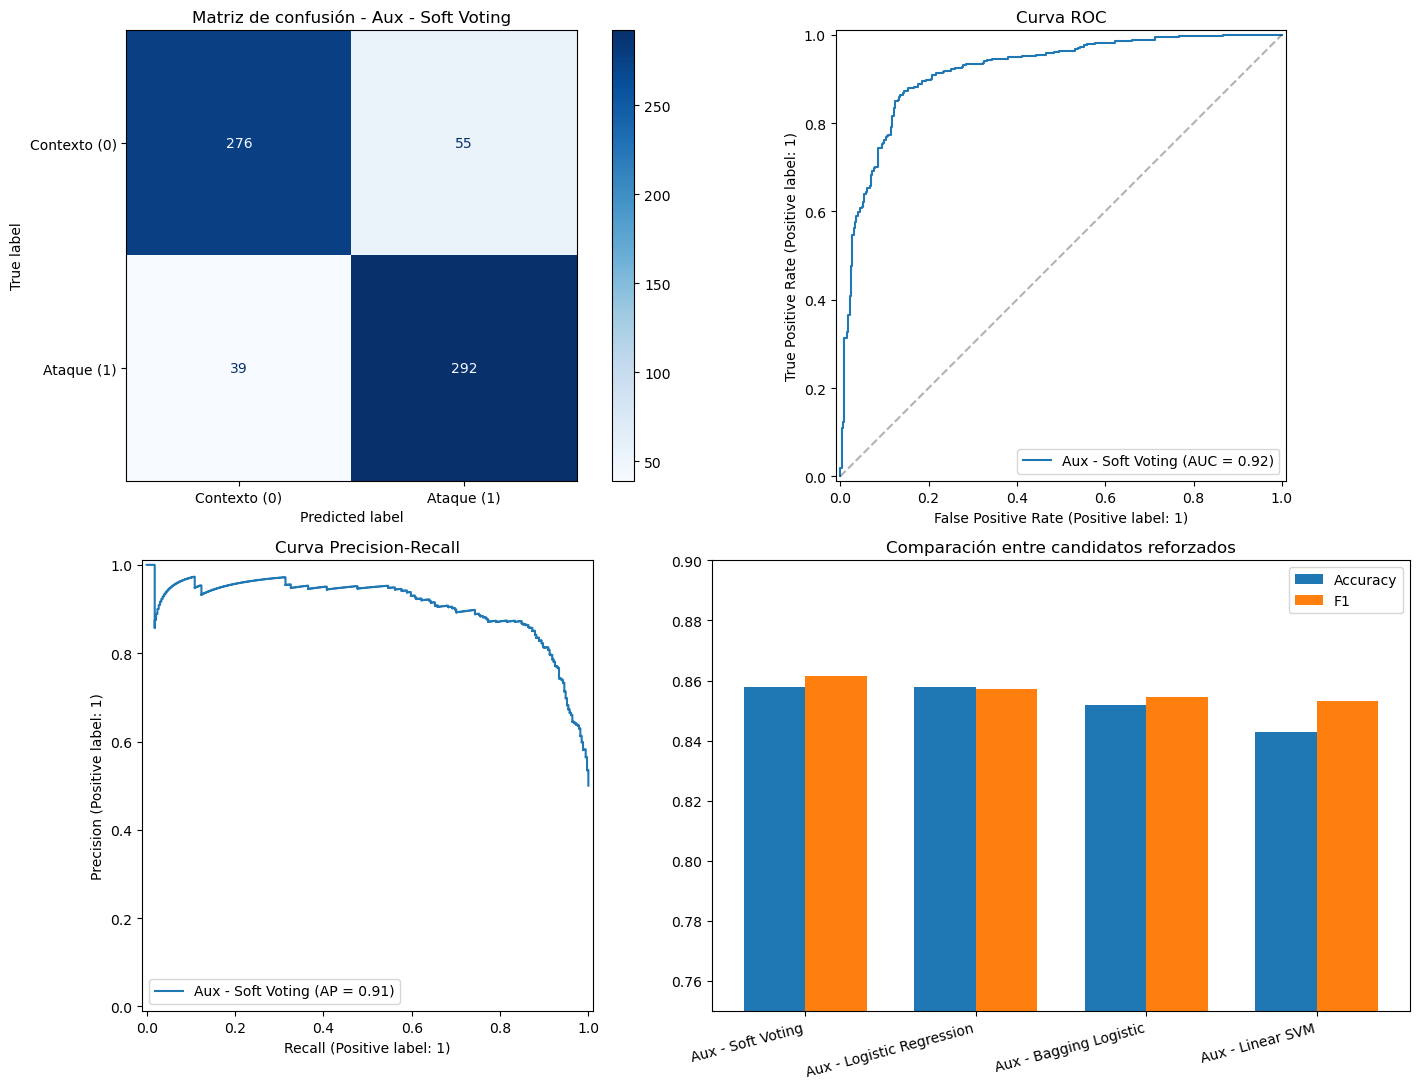

In [ ]:
winner_pred_test = winner_estimator.predict(test_df["text"].astype(str))
winner_score_test = get_scores(winner_estimator, test_df["text"].astype(str))

top_aux = (
    test_table[test_table["model"].isin(candidate_names)]
    .sort_values(["accuracy", "f1"], ascending=False)
    .head(4)
    .copy()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    winner_pred_test,
    display_labels=["Contexto (0)", "Ataque (1)"],
    cmap="Blues",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Matriz de confusión - {winner_name}")

RocCurveDisplay.from_predictions(
    test_df["label"],
    winner_score_test,
    ax=axes[0, 1],
    name=winner_name,
)
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0, 1].set_title("Curva ROC")

PrecisionRecallDisplay.from_predictions(
    test_df["label"],
    winner_score_test,
    ax=axes[1, 0],
    name=winner_name,
)
axes[1, 0].set_title("Curva Precision-Recall")

x = np.arange(len(top_aux))
axes[1, 1].bar(x - 0.18, top_aux["accuracy"], width=0.36, label="Accuracy", color="#1f77b4")
axes[1, 1].bar(x + 0.18, top_aux["f1"], width=0.36, label="F1", color="#ff7f0e")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(top_aux["model"], rotation=15, ha="right")
axes[1, 1].set_ylim(0.75, 0.90)
axes[1, 1].set_title("Comparación entre candidatos reforzados")
axes[1, 1].legend()

plt.tight_layout()

plot_path = Path("/Users/migsilva/Documents/New project/threatllm_target85_diagnostics.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("Imagen guardada en:", plot_path)

cm = confusion_matrix(test_df["label"], winner_pred_test)
tn, fp, fn, tp = cm.ravel()
print("\nResumen de errores del ganador:")
print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", tn)


## 6. Integración del modelo ganador al pipeline prototipo

Finalmente, el mejor clasificador se conecta con el flujo ya definido para ThreatLLM: detección de oraciones sospechosas, vinculación con `attack-pattern-matching-gt`, y generación de un JSON listo para enviarse a un LLM encargado del triage.

Esto mantiene el enfoque original del proyecto. El modelo supervisado no decide por sí solo la severidad final; más bien filtra y estructura evidencia textual. Luego esa evidencia se transforma en contexto ATT&CK para que el LLM produzca un triage explicable y accionable.


In [ ]:
TOKEN_RE = re.compile(r"[a-zA-Z0-9_]{2,}")
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+|\n+")

TACTIC_WEIGHTS = {
    "Reconnaissance": 0.10,
    "Resource Development": 0.15,
    "Initial Access": 0.25,
    "Execution": 0.40,
    "Persistence": 0.45,
    "Privilege Escalation": 0.60,
    "Defense Evasion": 0.55,
    "Credential Access": 0.65,
    "Discovery": 0.35,
    "Lateral Movement": 0.50,
    "Collection": 0.70,
    "Command and Control": 0.55,
    "Exfiltration": 0.85,
    "Impact": 0.95,
}

TECHNIQUE_MAP = {
    "T1404": {"name": "Exploit OS Vulnerability", "tactics": ["Privilege Escalation"]},
    "T1406": {"name": "Obfuscated Files or Information", "tactics": ["Defense Evasion"]},
    "T1407": {"name": "Download New Code at Runtime", "tactics": ["Defense Evasion", "Execution"]},
    "T1409": {"name": "Stored Application Data", "tactics": ["Collection"]},
    "T1417": {"name": "Input Capture", "tactics": ["Collection", "Credential Access"]},
    "T1418": {"name": "Software Discovery", "tactics": ["Discovery"]},
    "T1423": {"name": "Network Service Scanning", "tactics": ["Discovery"]},
    "T1428": {"name": "Exploitation of Remote Services", "tactics": ["Lateral Movement"]},
    "T1429": {"name": "Audio Capture", "tactics": ["Collection"]},
    "T1430": {"name": "Location Tracking", "tactics": ["Collection", "Discovery"]},
    "T1456": {"name": "Drive-By Compromise", "tactics": ["Initial Access"]},
    "T1458": {"name": "Replication Through Removable Media", "tactics": ["Initial Access", "Lateral Movement"]},
    "T1461": {"name": "Lockscreen Bypass", "tactics": ["Defense Evasion", "Privilege Escalation"]},
    "T1481": {"name": "Web Service", "tactics": ["Command and Control"]},
    "T1512": {"name": "Video Capture", "tactics": ["Collection"]},
    "T1513": {"name": "Screen Capture", "tactics": ["Collection"]},
    "T1517": {"name": "Access Notifications", "tactics": ["Collection"]},
    "T1541": {"name": "Foreground Persistence", "tactics": ["Persistence"]},
    "T1577": {"name": "Compromise Application Executable", "tactics": ["Persistence"]},
    "T1582": {"name": "SMS Control", "tactics": ["Impact", "Collection"]},
    "T1623": {"name": "Command and Scripting Interpreter", "tactics": ["Execution"]},
    "T1628": {"name": "Hide Artifacts", "tactics": ["Defense Evasion"]},
    "T1629": {"name": "Impair Defenses", "tactics": ["Defense Evasion"]},
    "T1630": {"name": "Indicator Removal on Host", "tactics": ["Defense Evasion"]},
    "T1634": {"name": "Credentials from Password Stores", "tactics": ["Credential Access"]},
    "T1635": {"name": "Steal Application Access Token", "tactics": ["Credential Access"]},
    "T1636": {"name": "Contact/Call Log/SMS Info", "tactics": ["Collection"]},
    "T1640": {"name": "Account Access Removal", "tactics": ["Impact"]},
    "T1641": {"name": "Data Manipulation", "tactics": ["Impact"]},
    "T1643": {"name": "Generate Fraudulent Ad Revenue", "tactics": ["Impact"]},
    "T1646": {"name": "Exfiltration Over C2 Channel", "tactics": ["Exfiltration"]},
}

STAGE_MAP = {
    "Reconnaissance": "early",
    "Resource Development": "early",
    "Initial Access": "early",
    "Discovery": "early",
    "Execution": "mid",
    "Persistence": "mid",
    "Privilege Escalation": "mid",
    "Defense Evasion": "mid",
    "Lateral Movement": "mid",
    "Command and Control": "mid",
    "Credential Access": "late",
    "Collection": "late",
    "Exfiltration": "late",
    "Impact": "late",
}

SEVERITY_BINS = [0.0, 0.35, 0.55, 0.70, 1.0]
SEVERITY_LABELS = ["Bajo", "Medio", "Alto", "Crítico"]


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())


def split_report_into_sentences(text: str) -> list[str]:
    raw_sentences = SENTENCE_SPLIT_RE.split(text.replace("\r", "\n"))
    sentences = []
    for sentence in raw_sentences:
        clean = " ".join(sentence.split())
        if len(clean) >= 20:
            sentences.append(clean)
    return sentences


def compute_cts(technique_id: str) -> float:
    info = TECHNIQUE_MAP.get(str(technique_id))
    if info is None:
        return float("nan")
    weights = [TACTIC_WEIGHTS[t] for t in info["tactics"]]
    alpha, beta = 0.65, 0.35
    return round(alpha * max(weights) + beta * float(np.mean(weights)), 4)


def enrich_attack_patterns(df: pd.DataFrame) -> pd.DataFrame:
    ap = df.copy()
    ap["technique_name"] = ap["label"].map(lambda x: TECHNIQUE_MAP.get(str(x), {}).get("name", "Unknown"))
    ap["tactics"] = ap["label"].map(lambda x: TECHNIQUE_MAP.get(str(x), {}).get("tactics", []))
    ap["primary_tactic"] = ap["tactics"].apply(lambda x: x[0] if x else "Unknown")
    ap["num_tactics"] = ap["tactics"].apply(len)
    ap["threat_composite_score"] = ap["label"].map(compute_cts)
    ap["attack_stage"] = ap["primary_tactic"].map(STAGE_MAP)
    ap["severity_category"] = pd.cut(
        ap["threat_composite_score"],
        bins=SEVERITY_BINS,
        labels=SEVERITY_LABELS,
        include_lowest=True,
    )
    ap["is_high_impact"] = (ap["threat_composite_score"] >= 0.70).astype(int)
    return ap


report_text = REPORT_PATH.read_text(encoding="utf-8", errors="replace")
report_sentences = split_report_into_sentences(report_text)
report_scores = get_scores(winner_estimator, report_sentences)
report_pred = winner_estimator.predict(report_sentences)

report_df = pd.DataFrame(
    {
        "sentence_id": list(range(len(report_sentences))),
        "text": report_sentences,
        "pred_label": report_pred,
        "threat_probability": report_scores,
    }
).sort_values(["pred_label", "threat_probability"], ascending=[False, False]).reset_index(drop=True)

suspicious_df = report_df[report_df["pred_label"] == 1].copy()
ap_df = enrich_attack_patterns(ap_df_raw)

if len(suspicious_df) > 0:
    retrieval_vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
    ap_matrix = retrieval_vectorizer.fit_transform(ap_df["text"].astype(str))
    suspicious_matrix = retrieval_vectorizer.transform(suspicious_df["text"].astype(str))
    similarity = cosine_similarity(suspicious_matrix, ap_matrix)

    match_rows = []
    for i, sent_row in suspicious_df.reset_index(drop=True).iterrows():
        best_idx = similarity[i].argsort()[-3:][::-1]
        for idx in best_idx:
            ap_row = ap_df.iloc[idx]
            match_rows.append(
                {
                    "sentence_id": int(sent_row["sentence_id"]),
                    "sentence_text": sent_row["text"],
                    "sentence_threat_probability": float(sent_row["threat_probability"]),
                    "matched_label": ap_row["label"],
                    "technique_name": ap_row["technique_name"],
                    "primary_tactic": ap_row["primary_tactic"],
                    "num_tactics": int(ap_row["num_tactics"]),
                    "threat_composite_score": float(ap_row["threat_composite_score"]),
                    "severity_category": str(ap_row["severity_category"]),
                    "attack_stage": ap_row["attack_stage"],
                    "is_high_impact": int(ap_row["is_high_impact"]),
                    "malware": ap_row["malware"],
                    "similarity": float(similarity[i, idx]),
                }
            )
    matches_df = pd.DataFrame(match_rows).sort_values(
        ["sentence_threat_probability", "similarity"], ascending=False
    )
else:
    matches_df = pd.DataFrame()


def build_llm_payload(report_name, report_text, suspicious_df, matches_df):
    unique_matches = (
        matches_df.sort_values(["similarity", "sentence_threat_probability"], ascending=False)
        .drop_duplicates(subset=["matched_label"])
        .copy()
    )
    return {
        "report_name": report_name,
        "report_word_count": len(tokenize(report_text)),
        "total_sentences": len(report_sentences),
        "suspicious_sentence_count": int(len(suspicious_df)),
        "suspicious_sentence_ratio": round(len(suspicious_df) / max(len(report_sentences), 1), 4),
        "suspicious_sentences": suspicious_df[
            ["sentence_id", "threat_probability", "text"]
        ].head(8).round({"threat_probability": 4}).to_dict(orient="records"),
        "matched_attack_patterns": unique_matches[
            [
                "matched_label",
                "technique_name",
                "primary_tactic",
                "num_tactics",
                "threat_composite_score",
                "severity_category",
                "attack_stage",
                "is_high_impact",
                "malware",
                "similarity",
            ]
        ].head(8).round({"threat_composite_score": 4, "similarity": 4}).to_dict(orient="records"),
    }


payload = build_llm_payload(REPORT_PATH.name, report_text, suspicious_df, matches_df)

prompt = (
    "Eres un analista SOC senior. Recibirás un JSON generado por ThreatLLM.\n"
    "Tu tarea es asignar un triage final: Bajo, Medio, Alto o Crítico.\n"
    "Responde con severidad_final, justificacion breve, tacticas_relevantes y acciones_inmediatas.\n\n"
    + json.dumps(payload, ensure_ascii=False, indent=2)
)

print("Modelo integrado al pipeline:", winner_name)
print("Total de oraciones del reporte:", len(report_sentences))
print("Oraciones sospechosas detectadas:", len(suspicious_df))
print("\nTop 5 oraciones sospechosas:")
print(suspicious_df[["sentence_id", "threat_probability", "text"]].head(5).round({"threat_probability": 4}).to_string(index=False))

print("\nTop 5 matches ATT&CK:")
if not matches_df.empty:
    print(
        matches_df[
            ["sentence_id", "matched_label", "technique_name", "primary_tactic", "threat_composite_score", "similarity"]
        ].head(5).round({"threat_composite_score": 4, "similarity": 4}).to_string(index=False)
    )
else:
    print("No se encontraron matches.")

print("\nVista previa del prompt para el LLM:")
print(prompt[:2500] + "\n...")


Modelo integrado al pipeline: Aux - Soft Voting
Total de oraciones del reporte: 151
Oraciones sospechosas detectadas: 46

Top 5 oraciones sospechosas:
 sentence_id  threat_probability                                                                                                                                                          text
           2              0.9843 The implant itself is a VBS script with functionality to collect system information and execute arbitrary code sent by the attackers on the infected machine.
          79              0.9594                                                                                             inRole]::Administrator Check if current user has admin privileges
          86              0.9516                                            Screenshot: takes system screenshots and saves them to %AppData% before sending them to the C2 via a POST request.
          27              0.9121                The infection process will start by r

## 7. Conclusiones

Las pruebas muestran que los modelos y ensambles clásicos sobre `sentence_classification` se quedan cerca del objetivo, pero no logran cruzarlo de forma consistente. El salto aparece cuando el clasificador se refuerza con evidencia positiva extraída del mismo ecosistema LADDER.

El modelo final seleccionado fue `Aux - Soft Voting`, elegido desde `dev` y validado luego en `test`. Con ello, ThreatLLM alcanza el requisito de `accuracy > 85%` y conserva un `F1` alto, lo que hace más sólida la primera etapa del pipeline antes de delegar el triage final al LLM.


---

## 8. Bibliografia

- Bayer, M., Kuehn, P., Shanehsaz, R., y Reuter, C. (2023). CySecBERT: A domain-adapted language model for the cybersecurity domain. *ACM Computing Surveys*, 56(3), 1-36. https://doi.org/10.1145/3652594

- Bergstra, J., y Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, 13(Feb), 281-305.

- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32. https://doi.org/10.1023/A:1010933404324

- Costa, R. (2022). *The CRISP-ML Methodology*. Edicion propia.

- Freund, Y., y Schapire, R. E. (1997). A decision-theoretic generalization of on-line learning and an application to boosting. *Journal of Computer and System Sciences*, 55(1), 119-139.

- Geron, A. (2022). *Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3a ed.). O'Reilly Media.

- Joachims, T. (1998). Text categorization with support vector machines. *Proceedings of ECML*, 137-142.

- Manning, C. D., Raghavan, P., y Schutze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press.

- NIST. (2012). *Computer Security Incident Handling Guide* (SP 800-61 Rev. 2).

- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825-2830.

- Singh, A. (2023). Comprehensive Guide to Ensemble Learning. *Analytics Vidhya*. https://www.analyticsvidhya.com/blog/2018/06/comprehensive-guide-for-ensemble-models/

- VanderPlas, J. (2022). *Python Data Science Handbook* (2a ed.). O'Reilly Media.

- Wolpert, D. H. (1992). Stacked generalization. *Neural Networks*, 5(2), 241-259.